## Principle Component Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [7]:
# Load class labels (0 = ER-, 1 = ER+)
class_df = pd.read_csv("class.tsv", sep="\t", header=None)
class_labels = class_df[0].values

In [15]:
col_map_df = pd.read_csv("columns.tsv", sep="\t", comment="#")
gene_id_to_name = dict(zip(col_map_df["ID"].astype(str), col_map_df["GeneSymbol"]))

In [16]:
expr_df = pd.read_csv("filtered.tsv", sep="\t")
expr_df.columns = [col.strip() for col in expr_df.columns] 

In [18]:
gata3_expr = expr_df[gata3_id].values
xbp1_expr = expr_df[xbp1_id].values

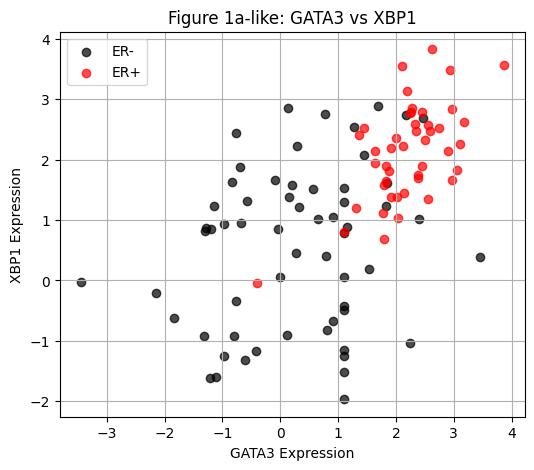

In [26]:
# Step 6: Scatter Plot of GATA3 vs XBP1 with specific colors
plt.figure(figsize=(6, 5))
for c in [0, 1]:
    mask = class_labels == c
    # Use red for ER- (c == 0) and blue for ER+ (c == 1)
    plt.scatter(gata3_expr[mask], xbp1_expr[mask], 
                label=f"ER{'+' if c == 1 else '-'}", 
                color='black' if c == 0 else 'red', alpha=0.7)

plt.xlabel("GATA3 Expression")
plt.ylabel("XBP1 Expression")
plt.title("Figure 1a-like: GATA3 vs XBP1")
plt.legend()
plt.grid(True)
plt.show()


In [20]:
X = np.vstack([gata3_expr, xbp1_expr]).T
X_centered = X - X.mean(axis=0)

pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_centered)

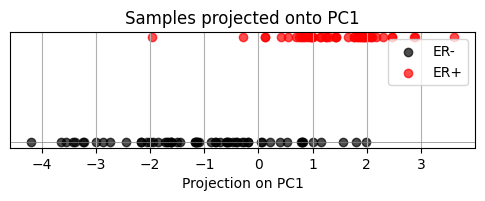

In [32]:
# Step 8: Plot projection onto PC1 with specific colors
plt.figure(figsize=(6, 1.5))
for c in [0, 1]:
    mask = class_labels == c
    # Use red for ER- (c == 0) and blue for ER+ (c == 1)
    plt.scatter(X_pca[mask], np.zeros_like(X_pca[mask]) + c * 0.1, 
                label=f"ER{'+' if c == 1 else '-'}", 
                color='black' if c == 0 else 'red', alpha=0.7)

plt.axhline(0, color='gray', linewidth=0.5)
plt.yticks([])  # Hide y-axis ticks
plt.xlabel("Projection on PC1")
plt.title("Samples projected onto PC1")
plt.legend()
plt.grid(True)
plt.show()